# Classification audio avec CNN sur spectrogrammes log-mel

## Objectif
Ce notebook a pour objectif de construire un pipeline complet de classification audio à partir de fichiers `.mp3`.

Le pipeline suit les étapes suivantes :
1. Chargement des métadonnées
2. Vérification de l'existence des fichiers audio
3. Génération des spectrogrammes log-mel
4. Préparation des labels
5. Séparation train / validation / test
6. Construction des `Dataset` et `DataLoader` PyTorch
7. Définition et entraînement d'un CNN
8. Évaluation finale sur le jeu de test
9. Export des résultats

## Intérêt de cette approche
Les fichiers audio sont transformés en spectrogrammes log-mel, qui représentent l'énergie fréquentielle dans le temps. Cette représentation est bien adaptée aux CNN, car elle peut être traitée comme une image.

## Positionnement méthodologique

Nous avons volontairement construit le pipeline CNN à partir de la source brute officielle du dataset FMA (`tracks.csv` et fichiers audio `.mp3`) afin de conserver une approche **Audio Native**.

Ce choix permet de distinguer clairement deux stratégies au sein du projet :

- une approche tabulaire fondée sur des variables extraites,
- une approche deep learning directement fondée sur le signal audio.

Cette séparation méthodologique garantit que les deux pipelines sont indépendants, tout en restant comparables dans leurs résultats.

## Résultat attendu
À la fin du notebook, nous obtenons :
- un modèle CNN entraîné,
- une métrique de performance sur le jeu de test,
- des courbes d'entraînement,
- un fichier CSV récapitulatif des résultats.

## Vérification de l'environnement

Cette cellule permet de vérifier que PyTorch est bien installé et que le GPU est disponible si la machine en possède un.

In [2]:
import torch

print(f"Version PyTorch : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"Device utilisé : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Version PyTorch : 2.6.0+cu124
CUDA disponible : True
Device utilisé : cuda


## Imports

Nous regroupons ici tous les imports du notebook pour éviter les doublons et rendre le code plus lisible.

In [3]:
import os
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

C:\Users\jayso\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration globale

Cette cellule centralise tous les paramètres importants du notebook :

- chemins vers les données,
- paramètres audio,
- hyperparamètres d'entraînement,
- seed de reproductibilité.

Les chemins sont définis de manière portable à partir du dossier courant du projet afin que le notebook puisse être exécuté sur une autre machine sans modification manuelle.

In [5]:
warnings.filterwarnings("ignore")

from pathlib import Path

BASE_DIR = Path.cwd()

CONFIG = {
    # chemins
    "audio_dir": BASE_DIR / "fma_small",
    "metadata_csv": BASE_DIR / "fma_metadata" / "tracks.csv",
    "spectro_dir": BASE_DIR / "spectrogrammes",

    # audio
    "sample_rate": 22050,
    "duration": 30.0,
    "n_mels": 128,
    "hop_length": 512,
    "n_fft": 2048,

    # entraînement
    "batch_size": 32,
    "num_epochs": 80,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 15,

    # reproductibilité
    "seed": 42,

    # dataloader
    "num_workers": 0
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

AUDIO_DIR = str(CONFIG["audio_dir"])
METADATA_CSV = str(CONFIG["metadata_csv"])
SPECTRO_DIR = str(CONFIG["spectro_dir"])

os.makedirs(SPECTRO_DIR, exist_ok=True)

print("Configuration chargée.")
print("BASE_DIR =", BASE_DIR)
print("AUDIO_DIR =", AUDIO_DIR)
print("METADATA_CSV =", METADATA_CSV)
print("SPECTRO_DIR =", SPECTRO_DIR)
print("audio_dir existe ?", os.path.exists(AUDIO_DIR))
print("metadata_csv existe ?", os.path.exists(METADATA_CSV))
print("Device =", DEVICE)

Configuration chargée.
BASE_DIR = c:\Users\jayso\Documents\projet-ml
AUDIO_DIR = c:\Users\jayso\Documents\projet-ml\fma_small
METADATA_CSV = c:\Users\jayso\Documents\projet-ml\fma_metadata\tracks.csv
SPECTRO_DIR = c:\Users\jayso\Documents\projet-ml\spectrogrammes
audio_dir existe ? True
metadata_csv existe ? True
Device = cuda


In [7]:
print("Contenu de BASE_DIR :")
print(os.listdir(BASE_DIR))

print("\nContenu de fma_small :")
print(os.listdir(os.path.join(BASE_DIR, "fma_small"))[:10])

print("\nContenu de fma_metadata :")
print(os.listdir(os.path.join(BASE_DIR, "fma_metadata")))

Contenu de BASE_DIR :
['.git', '.gitignore', 'best_audio_cnn.pth', 'best_audio_cnn_clean.pth', 'best_audio_cnn_recovered.pth', 'best_audio_cnn_v2.pth', 'best_model_doc_compliant.pth', 'best_model_v3.pth', 'CHEMIN_VERS_DOSSIER_SPECTROGRAMMES', 'Corrections_Jayson.docx', 'features_V2.csv', 'features_V2_CNN.csv', 'fma_metadata', 'fma_small', 'Noebook DeepLearning CNN.ipynb', 'Notebook 3 Logistic Regression and Random Forest.ipynb', 'Notebook Deep Learning CNN V2.ipynb', 'Notebook Deep Learning CNN V2_BACKUP.ipynb', 'Notebook Deep Learning CNN V2_FINAL.ipynb', 'NOTEBOOK1_EDA.ipynb', 'NOTEBOOK2BIS_V1_V2.ipynb', 'NOTEBOOK2_FEATURES.ipynb', 'NOTEBOOK5_MISMATCH_SUBGENRES.ipynb', 'Notebook_Phase3_DeepLearning.ipynb', 'prediction_pytorch.png', 'README.md', 'results_cnn_clean_recovered.csv', 'results_jayson_cnn.csv', 'spectrogrammes', 'spectrograms_npy', 'test_idx_cnn.npy', 'training_curves_cnn_clean_recovered.png', 'training_history_cnn_clean_recovered.csv', 'train_idx_cnn.npy', 'V2 Notebook 3 L

In [8]:
def get_audio_path(audio_dir: str, track_id: int) -> str:
    """
    Construit le chemin du fichier audio à partir du track_id.
    Exemple : 2 -> 000/000002.mp3
    """
    tid_str = f"{int(track_id):06d}"
    folder = tid_str[:3]
    return os.path.join(audio_dir, folder, f"{tid_str}.mp3")

In [9]:
print("AUDIO_DIR =", AUDIO_DIR)

path_from_function = get_audio_path(AUDIO_DIR, 2)
path_manual = os.path.join(BASE_DIR, "fma_small", "000", "000002.mp3")

print("Chemin reconstruit par get_audio_path :", path_from_function)
print("Existe (fonction) ?", os.path.exists(path_from_function))

print("Chemin manuel :", path_manual)
print("Existe (manuel) ?", os.path.exists(path_manual))

print("Les deux chemins sont identiques ?", path_from_function == path_manual)

AUDIO_DIR = c:\Users\jayso\Documents\projet-ml\fma_small
Chemin reconstruit par get_audio_path : c:\Users\jayso\Documents\projet-ml\fma_small\000\000002.mp3
Existe (fonction) ? True
Chemin manuel : c:\Users\jayso\Documents\projet-ml\fma_small\000\000002.mp3
Existe (manuel) ? True
Les deux chemins sont identiques ? True


In [10]:
test_audio_path = os.path.join(BASE_DIR, "fma_small", "000", "000002.mp3")

print("Test chemin audio :", test_audio_path)
print("Existe ?", os.path.exists(test_audio_path))

Test chemin audio : c:\Users\jayso\Documents\projet-ml\fma_small\000\000002.mp3
Existe ? True


## Reproductibilité

Pour obtenir des résultats plus stables et faciliter la comparaison des expériences, nous fixons les graines aléatoires.

In [11]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Seed fixée à {CONFIG['seed']}")

Seed fixée à 42


In [12]:
def create_log_mel_spectrogram(
    audio_path: str,
    sr: int = 22050,
    duration: float = 30.0,
    n_mels: int = 128,
    hop_length: int = 512,
    n_fft: int = 2048
):
    y, sr = librosa.load(audio_path, sr=sr, mono=True, duration=duration)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel, sr

In [11]:
print("create_log_mel_spectrogram" in globals())

True


## Fonctions utilitaires audio

Nous définissons ici :
- une fonction pour reconstruire le chemin vers un fichier audio à partir de son identifiant,
- une fonction pour calculer un spectrogramme log-mel.

Le spectrogramme log-mel sera la représentation d'entrée du CNN.

In [13]:
example_track_id = 2
example_audio_path = get_audio_path(AUDIO_DIR, example_track_id)

print("Chemin exemple :", example_audio_path)
print("Existe ?", os.path.exists(example_audio_path))

spec, sr = create_log_mel_spectrogram(
    example_audio_path,
    sr=CONFIG["sample_rate"],
    duration=CONFIG["duration"],
    n_mels=CONFIG["n_mels"],
    hop_length=CONFIG["hop_length"],
    n_fft=CONFIG["n_fft"]
)

print("Shape du spectrogramme :", spec.shape)
print("Sample rate :", sr)

Chemin exemple : c:\Users\jayso\Documents\projet-ml\fma_small\000\000002.mp3
Existe ? True
Shape du spectrogramme : (128, 1291)
Sample rate : 22050


## Vérification visuelle d'un spectrogramme

Avant de lancer le pipeline complet, il est utile de vérifier visuellement qu'un spectrogramme est correctement généré sur un exemple.

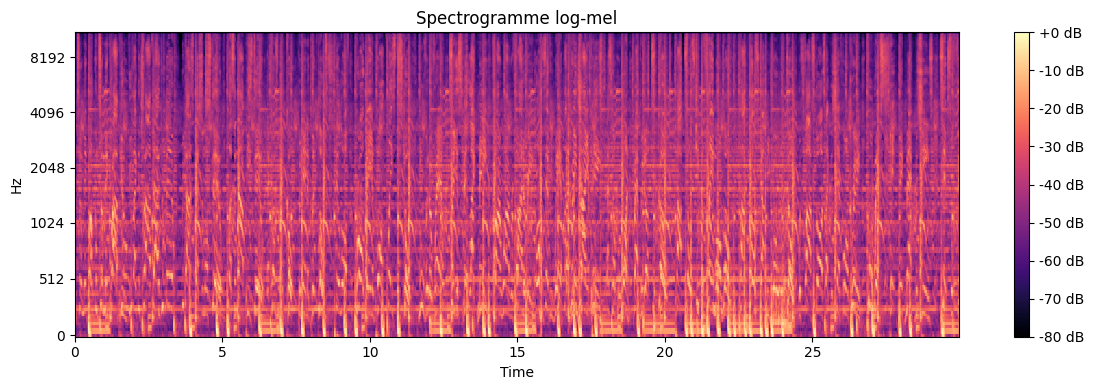

In [14]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(spec, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogramme log-mel")
plt.tight_layout()
plt.show()

## Remarque méthodologique sur la fenêtre audio

Dans ce pipeline, les spectrogrammes sont calculés à partir des **30 premières secondes** de chaque morceau. Ce choix permet de standardiser l'entrée du CNN et de conserver un protocole simple, reproductible et compatible avec le budget de calcul du projet.

Nous notons qu'une alternative possible aurait consisté à centrer la fenêtre d'écoute sur le cœur du morceau. Ce raffinement méthodologique pourrait être exploré dans un travail futur, mais n'a pas été retenu ici afin de conserver un pipeline stable et cohérent avec les spectrogrammes déjà pré-calculés.

Ainsi, dans cette version du projet, le CNN apprend principalement à partir de la texture d'entrée en matière des morceaux, tandis que l'approche tabulaire repose sur une représentation plus agrégée du signal.

## Chargement des métadonnées

Nous chargeons ici le fichier CSV contenant les informations sur les pistes audio.
Nous ajoutons ensuite :
- le chemin complet vers chaque fichier audio,
- une colonne indiquant si le fichier existe réellement.

In [15]:
df = pd.read_csv(METADATA_CSV, header=[0, 1], index_col=0)

df.columns = [
    "_".join([str(level).strip() for level in col if str(level) != "nan"]).strip("_")
    for col in df.columns
]

df = df.reset_index().rename(columns={"index": "track_id"})

print("Dimensions du CSV :", df.shape)
print(df.columns[:20].tolist())

Dimensions du CSV : (106574, 53)
['track_id', 'album_comments', 'album_date_created', 'album_date_released', 'album_engineer', 'album_favorites', 'album_id', 'album_information', 'album_listens', 'album_producer', 'album_tags', 'album_title', 'album_tracks', 'album_type', 'artist_active_year_begin', 'artist_active_year_end', 'artist_associated_labels', 'artist_bio', 'artist_comments', 'artist_date_created']


## Vérification de la disponibilité des fichiers audio

Nous relions chaque identifiant de piste à son chemin audio réel, puis nous vérifions l'existence du fichier.
Cette étape permet d'éliminer proprement les entrées invalides avant le calcul des spectrogrammes.

In [16]:
cols_to_check = [
    "track_id",
    "track_genre_top",
    "artist_name"
]

for col in cols_to_check:
    print(col, "->", col in df.columns)

TRACK_ID_COL = "track_id"
TARGET_COL = "track_genre_top"
GROUP_COL = "artist_name"

print("TRACK_ID_COL =", TRACK_ID_COL)
print("TARGET_COL =", TARGET_COL)
print("GROUP_COL =", GROUP_COL)

track_id -> True
track_genre_top -> True
artist_name -> True
TRACK_ID_COL = track_id
TARGET_COL = track_genre_top
GROUP_COL = artist_name


## Filtrage des données valides

Nous conservons uniquement les lignes pour lesquelles le fichier audio existe.
Ce sous-ensemble constitue la base de travail pour la génération des spectrogrammes.

In [17]:
df["audio_path"] = df[TRACK_ID_COL].apply(lambda x: get_audio_path(AUDIO_DIR, x))
df["file_exists"] = df["audio_path"].apply(os.path.exists)

print("Nombre de fichiers trouvés :", df["file_exists"].sum())
print("Nombre total de lignes :", len(df))

display(df[[TRACK_ID_COL, TARGET_COL, GROUP_COL, "audio_path", "file_exists"]].head())
df_work = df[
    (df["file_exists"] == True) &
    (df[TARGET_COL].notna())
].copy()

print("Nombre de lignes exploitables :", len(df_work))
display(df_work[[TRACK_ID_COL, TARGET_COL, GROUP_COL, "file_exists"]].head())

Nombre de fichiers trouvés : 8000
Nombre total de lignes : 106574


,track_id,track_genre_top,artist_name,audio_path,file_exists
0,2,Hip-Hop,AWOL,c:\Users\jayso\Documents\projet-ml\fma_small\0...,True
1,3,Hip-Hop,AWOL,c:\Users\jayso\Documents\projet-ml\fma_small\0...,False
2,5,Hip-Hop,AWOL,c:\Users\jayso\Documents\projet-ml\fma_small\0...,True
3,10,Pop,Kurt Vile,c:\Users\jayso\Documents\projet-ml\fma_small\0...,True
4,20,NaN,Nicky Cook,c:\Users\jayso\Documents\projet-ml\fma_small\0...,False


Nombre de lignes exploitables : 8000


,track_id,track_genre_top,artist_name,file_exists
0,2,Hip-Hop,AWOL,True
2,5,Hip-Hop,AWOL,True
3,10,Pop,Kurt Vile,True
15,140,Folk,Alec K. Redfearn & the Eyesores,True
16,141,Folk,Alec K. Redfearn & the Eyesores,True


In [18]:
le = LabelEncoder()
df_work["target"] = le.fit_transform(df_work[TARGET_COL])

print("Nombre de classes :", len(le.classes_))
print("Classes :", list(le.classes_))

Nombre de classes : 8
Classes : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


In [19]:
print("Nombre de valeurs manquantes dans GROUP_COL :", df_work[GROUP_COL].isna().sum())
print("Nombre de groupes uniques :", df_work[GROUP_COL].nunique())

Nombre de valeurs manquantes dans GROUP_COL : 0
Nombre de groupes uniques : 2306


## Séparation train / validation / test

Nous construisons trois sous-ensembles :
- entraînement,
- validation,
- test.

Le split est réalisé en deux étapes :
1. séparation train_val / test,
2. séparation train / validation à l'intérieur de train_val.

Nous utilisons `GroupShuffleSplit` pour respecter la contrainte de groupe.

In [20]:
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=CONFIG["seed"])
train_val_idx, test_idx = next(
    gss_1.split(df_work, y=df_work["target"], groups=df_work[GROUP_COL])
)

df_train_val = df_work.iloc[train_val_idx].copy()
df_test = df_work.iloc[test_idx].copy()

gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.1111, random_state=CONFIG["seed"])
train_idx_rel, val_idx_rel = next(
    gss_2.split(df_train_val, y=df_train_val["target"], groups=df_train_val[GROUP_COL])
)

df_train = df_train_val.iloc[train_idx_rel].copy()
df_val = df_train_val.iloc[val_idx_rel].copy()

print("Train :", len(df_train))
print("Validation :", len(df_val))
print("Test :", len(df_test))
print("Total :", len(df_train) + len(df_val) + len(df_test))

Train : 6299
Validation : 746
Test : 955
Total : 8000


## Vérification de la distribution des classes

Cette étape permet de vérifier que les classes restent raisonnablement représentées dans chaque sous-ensemble.

In [21]:
print("Classes dans train :", sorted(df_train["target"].unique()))
print("Classes dans validation :", sorted(df_val["target"].unique()))
print("Classes dans test :", sorted(df_test["target"].unique()))

Classes dans train : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Classes dans validation : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Classes dans test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [22]:
os.makedirs(SPECTRO_DIR, exist_ok=True)

print("SPECTRO_DIR =", SPECTRO_DIR)
print("Le dossier existe ?", os.path.exists(SPECTRO_DIR))
print("Nombre de fichiers déjà présents :", len(os.listdir(SPECTRO_DIR)))

SPECTRO_DIR = c:\Users\jayso\Documents\projet-ml\spectrogrammes
Le dossier existe ? True
Nombre de fichiers déjà présents : 7995


In [23]:
test_track_id = 2
test_audio_path = get_audio_path(AUDIO_DIR, test_track_id)
test_save_path = os.path.join(SPECTRO_DIR, f"{test_track_id:06d}.npy")

spec, sr = create_log_mel_spectrogram(
    test_audio_path,
    sr=CONFIG["sample_rate"],
    duration=CONFIG["duration"],
    n_mels=CONFIG["n_mels"],
    hop_length=CONFIG["hop_length"],
    n_fft=CONFIG["n_fft"]
)

np.save(test_save_path, spec.astype(np.float32))

print("Fichier sauvegardé :", test_save_path)
print("Existe ?", os.path.exists(test_save_path))
print("Shape sauvegardée :", np.load(test_save_path).shape)

Fichier sauvegardé : c:\Users\jayso\Documents\projet-ml\spectrogrammes\000002.npy
Existe ? True
Shape sauvegardée : (128, 1291)


## Génération et sauvegarde des spectrogrammes

Nous définissons ici une fonction qui parcourt l'ensemble des pistes audio valides et :

- charge chaque fichier audio,
- calcule son spectrogramme log-mel,
- sauvegarde le résultat au format `.npy`,
- enregistre les éventuelles erreurs de traitement.

Cette étape permet de pré-calculer les entrées du CNN une seule fois, ce qui rend l'entraînement beaucoup plus rapide et plus stable.

In [24]:
def process_and_save_spectrograms(df_input: pd.DataFrame, output_dir: str):
    valid_flags = []
    errors = []

    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Création des spectrogrammes"):
        track_id = int(row[TRACK_ID_COL])
        audio_path = row["audio_path"]
        save_path = os.path.join(output_dir, f"{track_id:06d}.npy")

        if os.path.exists(save_path):
            valid_flags.append(True)
            continue

        try:
            spec, _ = create_log_mel_spectrogram(
                audio_path=audio_path,
                sr=CONFIG["sample_rate"],
                duration=CONFIG["duration"],
                n_mels=CONFIG["n_mels"],
                hop_length=CONFIG["hop_length"],
                n_fft=CONFIG["n_fft"]
            )
            np.save(save_path, spec.astype(np.float32))
            valid_flags.append(True)

        except Exception as e:
            valid_flags.append(False)
            errors.append({
                "track_id": track_id,
                "audio_path": audio_path,
                "error": str(e)
            })

    return valid_flags, errors
print("process_and_save_spectrograms" in globals())

True


## Génération des spectrogrammes pour l'ensemble du dataset

Nous appliquons maintenant la fonction précédente à toutes les pistes exploitables.

À l'issue de cette étape :
- chaque piste valide doit avoir un fichier `.npy`,
- nous saurons combien de traitements ont réussi,
- nous pourrons isoler proprement les éventuelles erreurs.

In [25]:
valid_flags, errors = process_and_save_spectrograms(df_work, SPECTRO_DIR)

df_work["spectro_ok"] = valid_flags
df_final = df_work[df_work["spectro_ok"]].copy().reset_index(drop=True)

print("Nombre de spectrogrammes valides :", len(df_final))
print("Nombre d'erreurs :", len(errors))

Création des spectrogrammes: 100%|██████████| 8000/8000 [00:00<00:00, 10945.92it/s]

Nombre de spectrogrammes valides : 7994
Nombre d'erreurs : 6


## Inspection des erreurs de génération

Même si le nombre d'erreurs est faible, il est important de les visualiser pour comprendre si elles proviennent :
- de fichiers audio corrompus,
- de métadonnées incorrectes,
- ou d'un problème ponctuel de lecture.

Cette étape permet de documenter proprement les exclusions du pipeline.

In [26]:
if len(errors) > 0:
    df_errors = pd.DataFrame(errors)
    display(df_errors.head(10))
else:
    print("Aucune erreur.")

,track_id,audio_path,error
0,98565,c:\Users\jayso\Documents\projet-ml\fma_small\0...,
1,98567,c:\Users\jayso\Documents\projet-ml\fma_small\0...,
2,98569,c:\Users\jayso\Documents\projet-ml\fma_small\0...,
3,99134,c:\Users\jayso\Documents\projet-ml\fma_small\0...,
4,108925,c:\Users\jayso\Documents\projet-ml\fma_small\1...,
5,133297,c:\Users\jayso\Documents\projet-ml\fma_small\1...,


## Construction du dataset final

Nous conservons uniquement les observations pour lesquelles :
- le fichier audio existe,
- la cible est renseignée,
- le spectrogramme a bien été généré.

Ce sous-ensemble constitue la version finale du dataset utilisée pour l'entraînement du modèle.

In [27]:
print("Taille de df_final :", len(df_final))
display(df_final[[TRACK_ID_COL, TARGET_COL, GROUP_COL, "spectro_ok"]].head())

Taille de df_final : 7994


,track_id,track_genre_top,artist_name,spectro_ok
0,2,Hip-Hop,AWOL,True
1,5,Hip-Hop,AWOL,True
2,10,Pop,Kurt Vile,True
3,140,Folk,Alec K. Redfearn & the Eyesores,True
4,141,Folk,Alec K. Redfearn & the Eyesores,True


## Sauvegarde des métadonnées nettoyées

Nous enregistrons une version propre des métadonnées utilisées par le pipeline.
Cela permet de garder une trace exacte du jeu de données réellement exploité.

In [28]:
clean_csv_path = os.path.join(SPECTRO_DIR, "metadata_clean_for_cnn.csv")
df_final.to_csv(clean_csv_path, index=False)

print("CSV nettoyé sauvegardé :", clean_csv_path)
print("Le fichier existe ?", os.path.exists(clean_csv_path))

CSV nettoyé sauvegardé : c:\Users\jayso\Documents\projet-ml\spectrogrammes\metadata_clean_for_cnn.csv
Le fichier existe ? True


## Encodage final des labels sur le dataset nettoyé

Après exclusion des quelques fichiers en erreur, nous réappliquons l'encodage des labels sur le dataset final afin de garantir la cohérence entre les données effectivement utilisées et les indices de classes.

In [29]:
le = LabelEncoder()
df_final["target"] = le.fit_transform(df_final[TARGET_COL])

print("Taille de df_final :", len(df_final))
print("Nombre de classes :", len(le.classes_))
print("Classes :", list(le.classes_))

Taille de df_final : 7994
Nombre de classes : 8
Classes : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


## Ordre des labels de classification

Nous stockons explicitement ici l'ordre des labels utilisé par le `LabelEncoder`.

Cette information est utile pour :
- documenter la correspondance entre indices numériques et genres,
- garantir la cohérence avec les métriques par classe,
- faciliter la comparaison avec les autres notebooks du projet.

In [56]:
LABEL_COLS = list(le.classes_)

print("LABEL_COLS =", LABEL_COLS)
print("Nombre de labels =", len(LABEL_COLS))

LABEL_COLS = ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
Nombre de labels = 8


## Split définitif sur le dataset nettoyé

Après exclusion des fichiers dont le spectrogramme n'a pas pu être généré, nous refaisons la séparation
train / validation / test sur le dataset final.

Cela garantit que les trois sous-ensembles ne contiennent que des données réellement exploitables.

In [30]:
gss_1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=CONFIG["seed"])
train_val_idx, test_idx = next(
    gss_1.split(df_final, y=df_final["target"], groups=df_final[GROUP_COL])
)

df_train_val = df_final.iloc[train_val_idx].copy()
df_test = df_final.iloc[test_idx].copy()

gss_2 = GroupShuffleSplit(n_splits=1, test_size=0.1111, random_state=CONFIG["seed"])
train_idx_rel, val_idx_rel = next(
    gss_2.split(df_train_val, y=df_train_val["target"], groups=df_train_val[GROUP_COL])
)

df_train = df_train_val.iloc[train_idx_rel].copy()
df_val = df_train_val.iloc[val_idx_rel].copy()

print("Train :", len(df_train))
print("Validation :", len(df_val))
print("Test :", len(df_test))
print("Total :", len(df_train) + len(df_val) + len(df_test))

print("Classes dans train :", sorted(df_train["target"].unique()))
print("Classes dans validation :", sorted(df_val["target"].unique()))
print("Classes dans test :", sorted(df_test["target"].unique()))

Train : 6481
Validation : 723
Test : 790
Total : 7994
Classes dans train : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Classes dans validation : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Classes dans test : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


## Split définitif sur le dataset nettoyé

Le split train / validation / test est effectué uniquement sur le dataset final nettoyé (`df_final`), après exclusion des fichiers dont le spectrogramme n'a pas pu être généré.

Ce choix garantit que tous les sous-ensembles ne contiennent que des observations réellement exploitables et évite toute incohérence entre un split intermédiaire et le split finalement utilisé pour l'entraînement.

## Vérification de l'isolement des artistes entre les splits

Afin de garantir l'absence de fuite d'information entre les sous-ensembles, nous vérifions explicitement qu'aucun artiste n'apparaît simultanément dans train, validation et test.

In [31]:
artists_train = set(df_train[GROUP_COL])
artists_val = set(df_val[GROUP_COL])
artists_test = set(df_test[GROUP_COL])

assert len(artists_train & artists_test) == 0, "Leakage train/test !"
assert len(artists_train & artists_val) == 0, "Leakage train/val !"
assert len(artists_val & artists_test) == 0, "Leakage val/test !"

print("OK — 0 artiste commun entre train, validation et test")
print("Intersection train/test :", len(artists_train & artists_test))
print("Intersection train/val :", len(artists_train & artists_val))
print("Intersection val/test :", len(artists_val & artists_test))

OK — 0 artiste commun entre train, validation et test
Intersection train/test : 0
Intersection train/val : 0
Intersection val/test : 0


## Sauvegarde des indices du split

Nous sauvegardons ici les indices et les identifiants de pistes des jeux d'entraînement, de validation et de test afin d'assurer la traçabilité du protocole et la comparabilité avec les autres membres du groupe.

In [32]:
outputs_split_dir = BASE_DIR / "outputs" / "splits"
outputs_split_dir.mkdir(parents=True, exist_ok=True)

np.save(outputs_split_dir / "train_idx_jayson.npy", df_train.index.to_numpy())
np.save(outputs_split_dir / "val_idx_jayson.npy", df_val.index.to_numpy())
np.save(outputs_split_dir / "test_idx_jayson.npy", df_test.index.to_numpy())

np.save(outputs_split_dir / "train_track_ids_jayson.npy", df_train[TRACK_ID_COL].to_numpy())
np.save(outputs_split_dir / "val_track_ids_jayson.npy", df_val[TRACK_ID_COL].to_numpy())
np.save(outputs_split_dir / "test_track_ids_jayson.npy", df_test[TRACK_ID_COL].to_numpy())

print("Fichiers de split sauvegardés dans :", outputs_split_dir)
print("train_idx existe ?", (outputs_split_dir / "train_idx_jayson.npy").exists())
print("val_idx existe ?", (outputs_split_dir / "val_idx_jayson.npy").exists())
print("test_idx existe ?", (outputs_split_dir / "test_idx_jayson.npy").exists())

Fichiers de split sauvegardés dans : c:\Users\jayso\Documents\projet-ml\outputs\splits
train_idx existe ? True
val_idx existe ? True
test_idx existe ? True


## Définition du Dataset PyTorch

Nous définissons ici une classe `Dataset` compatible avec PyTorch.

Son rôle est de :
- charger les spectrogrammes sauvegardés au format `.npy`,
- récupérer le label correspondant,
- normaliser chaque spectrogramme,
- ajouter une dimension de canal pour l'entrée du CNN.

Cette étape rend le pipeline d'entraînement propre, réutilisable et lisible.

In [34]:
class FMASpectrogramDataset(Dataset):
    def __init__(self, df_data: pd.DataFrame, spectro_dir: str):
        self.df = df_data.reset_index(drop=True)
        self.spectro_dir = spectro_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        track_id = int(row[TRACK_ID_COL])
        label = int(row["target"])

        spec_path = os.path.join(self.spectro_dir, f"{track_id:06d}.npy")
        x = np.load(spec_path).astype(np.float32)

        # normalisation par échantillon
        x = (x - x.mean()) / (x.std() + 1e-8)

        # ajout du canal : [1, H, W]
        x = np.expand_dims(x, axis=0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.long)

        return x, y

In [35]:
print("FMASpectrogramDataset" in globals())

True


## Création des objets Dataset

Nous instancions maintenant trois jeux de données PyTorch :
- un pour l'entraînement,
- un pour la validation,
- un pour le test.

Chaque objet `Dataset` s'appuie sur le DataFrame correspondant et sur le dossier contenant les spectrogrammes pré-calculés.

## Vérification d'un échantillon

Avant de créer les `DataLoader`, nous vérifions qu'un exemple du `Dataset` est correctement chargé.

Nous voulons contrôler :
- la forme du tenseur d'entrée,
- le type du label,
- la cohérence générale des données retournées.

In [36]:
train_dataset = FMASpectrogramDataset(df_train, SPECTRO_DIR)
val_dataset = FMASpectrogramDataset(df_val, SPECTRO_DIR)
test_dataset = FMASpectrogramDataset(df_test, SPECTRO_DIR)

print("Taille train_dataset :", len(train_dataset))
print("Taille val_dataset :", len(val_dataset))
print("Taille test_dataset :", len(test_dataset))

x_sample, y_sample = train_dataset[0]

print("Shape de x_sample :", x_sample.shape)
print("Type de x_sample :", x_sample.dtype)
print("Valeur de y_sample :", y_sample.item())
print("Type de y_sample :", y_sample.dtype)

Taille train_dataset : 6481
Taille val_dataset : 723
Taille test_dataset : 790
Shape de x_sample : torch.Size([1, 128, 1291])
Type de x_sample : torch.float32
Valeur de y_sample : 3
Type de y_sample : torch.int64


## Création des DataLoader

Les `DataLoader` permettent de charger les données par batch pendant l'entraînement et l'évaluation.

Nous utilisons :
- `shuffle=True` pour le jeu d'entraînement,
- `shuffle=False` pour validation et test.

In [37]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"]
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"]
)

print("Nombre de batches train :", len(train_loader))
print("Nombre de batches validation :", len(val_loader))
print("Nombre de batches test :", len(test_loader))

Nombre de batches train : 203
Nombre de batches validation : 23
Nombre de batches test : 25


## Uniformisation de la taille des spectrogrammes

Les spectrogrammes générés à partir des fichiers audio n'ont pas toujours exactement la même largeur temporelle.

Or, pour former des batchs avec PyTorch, toutes les entrées doivent avoir la même dimension.

Nous définissons donc ici une fonction qui :
- tronque les spectrogrammes trop longs,
- ajoute du padding (zéros) aux spectrogrammes trop courts.

Nous fixons ainsi une largeur temporelle unique pour tout le dataset.

## Mise à jour du Dataset PyTorch

Nous modifions maintenant la classe `Dataset` pour garantir que chaque spectrogramme chargé possède exactement la même taille avant d'être converti en tenseur.

Cette correction permet au `DataLoader` de constituer correctement des batchs.

In [38]:
TARGET_TIME_FRAMES = 1291

def pad_or_truncate_spectrogram(spec: np.ndarray, target_frames: int = TARGET_TIME_FRAMES) -> np.ndarray:
    """
    Force un spectrogramme à avoir exactement `target_frames` colonnes.
    - Si trop long : troncature
    - Si trop court : padding avec des zéros
    """
    current_frames = spec.shape[1]

    if current_frames > target_frames:
        spec = spec[:, :target_frames]
    elif current_frames < target_frames:
        pad_width = target_frames - current_frames
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode="constant")

    return spec

In [39]:
class FMASpectrogramDataset(Dataset):
    def __init__(self, df_data: pd.DataFrame, spectro_dir: str, target_frames: int = TARGET_TIME_FRAMES):
        self.df = df_data.reset_index(drop=True)
        self.spectro_dir = spectro_dir
        self.target_frames = target_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        track_id = int(row[TRACK_ID_COL])
        label = int(row["target"])

        spec_path = os.path.join(self.spectro_dir, f"{track_id:06d}.npy")
        x = np.load(spec_path).astype(np.float32)

        # uniformisation de la largeur temporelle
        x = pad_or_truncate_spectrogram(x, self.target_frames)

        # normalisation par échantillon
        x = (x - x.mean()) / (x.std() + 1e-8)

        # ajout du canal : [1, H, W]
        x = np.expand_dims(x, axis=0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.long)

        return x, y

## Recréation des objets Dataset

Après modification de la classe `Dataset`, nous recréons les objets train, validation et test pour qu'ils utilisent la nouvelle logique d'uniformisation.

In [40]:
train_dataset = FMASpectrogramDataset(df_train, SPECTRO_DIR)
val_dataset = FMASpectrogramDataset(df_val, SPECTRO_DIR)
test_dataset = FMASpectrogramDataset(df_test, SPECTRO_DIR)

x_sample, y_sample = train_dataset[0]
print("Shape de x_sample :", x_sample.shape)
print("Valeur de y_sample :", y_sample.item())

Shape de x_sample : torch.Size([1, 128, 1291])
Valeur de y_sample : 3


## Recréation des DataLoader

Nous recréons les `DataLoader` afin qu'ils utilisent les nouveaux objets `Dataset` corrigés.

In [41]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"]
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"]
)

In [42]:
x_batch, y_batch = next(iter(train_loader))

print("Shape de x_batch :", x_batch.shape)
print("Shape de y_batch :", y_batch.shape)
print("Type de x_batch :", x_batch.dtype)
print("Type de y_batch :", y_batch.dtype)

Shape de x_batch : torch.Size([32, 1, 128, 1291])
Shape de y_batch : torch.Size([32])
Type de x_batch : torch.float32
Type de y_batch : torch.int64


## Définition du modèle CNN final

Nous utilisons ici une architecture convolutionnelle plus expressive que la baseline initiale.

Par rapport à une tête de classification très compacte, ce modèle conserve davantage d'information après les couches convolutionnelles grâce à un `AdaptiveAvgPool2d((4, 4))`, puis utilise deux couches entièrement connectées avec dropout.

Cette architecture correspond à une version ayant déjà donné de meilleures performances expérimentales sur ce projet.

In [43]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(F.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [44]:
print("AudioCNN" in globals())

True


## Initialisation du modèle et des objets d'apprentissage

Nous créons ici :
- le modèle CNN,
- la fonction de coût,
- l'optimiseur,
- le scheduler de learning rate.

Le nombre de classes est automatiquement déduit du `LabelEncoder`.

## Mise à jour des hyperparamètres d'entraînement

Nous réutilisons ici les réglages qui ont déjà donné de meilleures performances :
- 80 époques maximum,
- early stopping plus tolérant,
- scheduler moins agressif.

In [45]:
CONFIG["num_epochs"] = 80
CONFIG["patience"] = 15

model = AudioCNN(num_classes=len(le.classes_)).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

print("F importé :", "F" in globals())
print("Modèle réinitialisé sur :", DEVICE)
print("Nombre d'époques max :", CONFIG["num_epochs"])
print("Patience early stopping :", CONFIG["patience"])

F importé : False
Modèle réinitialisé sur : cuda
Nombre d'époques max : 80
Patience early stopping : 15


In [46]:
import torch.nn.functional as F

## Fonctions d'entraînement et d'évaluation

Nous définissons ici deux fonctions utilitaires :

- `run_train_epoch` pour exécuter une époque d'entraînement,
- `run_eval_epoch` pour évaluer le modèle sur un jeu de validation ou de test.

Cette séparation rend la boucle d'entraînement plus lisible et plus facile à maintenir.

In [47]:
def run_train_epoch(model, loader, criterion, optimizer, device): 
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    return epoch_loss, epoch_f1


@torch.no_grad()
def run_eval_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    return epoch_loss, epoch_f1, all_targets, all_preds

In [48]:
print("run_train_epoch" in globals())
print("run_eval_epoch" in globals())

True
True


## Entraînement du modèle avec les hyperparamètres ajustés

Nous relançons maintenant l'entraînement avec :
- l'architecture CNN enrichie,
- 80 époques maximum,
- un early stopping plus tolérant.

L'objectif est de se rapprocher des meilleures performances observées précédemment.

In [49]:
history = {
    "train_loss": [],
    "train_f1": [],
    "val_loss": [],
    "val_f1": []
}

best_val_f1 = -np.inf
best_model_path = os.path.join(BASE_DIR, "best_audio_cnn_recovered.pth")
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(CONFIG["num_epochs"]):
    train_loss, train_f1 = run_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_f1, _, _ = run_eval_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch [{epoch+1}/{CONFIG['num_epochs']}] | "
        f"train_loss={train_loss:.4f} | train_f1={train_f1:.4f} | "
        f"val_loss={val_loss:.4f} | val_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> nouveau meilleur modèle sauvegardé")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= CONFIG["patience"]:
        print("Early stopping déclenché.")
        break

training_time_s = time.time() - start_time

print("Temps d'entraînement (s) :", round(training_time_s, 2))
print("Meilleur F1 validation :", round(best_val_f1, 4))
print("Modèle sauvegardé :", best_model_path)

Epoch [1/80] | train_loss=1.7220 | train_f1=0.3335 | val_loss=1.7334 | val_f1=0.3243
  -> nouveau meilleur modèle sauvegardé
Epoch [2/80] | train_loss=1.4714 | train_f1=0.4567 | val_loss=1.5361 | val_f1=0.3698
  -> nouveau meilleur modèle sauvegardé
Epoch [3/80] | train_loss=1.3786 | train_f1=0.5084 | val_loss=1.4816 | val_f1=0.4584
  -> nouveau meilleur modèle sauvegardé
Epoch [4/80] | train_loss=1.3418 | train_f1=0.5227 | val_loss=1.4214 | val_f1=0.4612
  -> nouveau meilleur modèle sauvegardé
Epoch [5/80] | train_loss=1.2860 | train_f1=0.5416 | val_loss=1.3705 | val_f1=0.4677
  -> nouveau meilleur modèle sauvegardé
Epoch [6/80] | train_loss=1.2502 | train_f1=0.5593 | val_loss=1.7269 | val_f1=0.3968
Epoch [7/80] | train_loss=1.2244 | train_f1=0.5689 | val_loss=1.4182 | val_f1=0.4586
Epoch [8/80] | train_loss=1.1786 | train_f1=0.5817 | val_loss=1.5049 | val_f1=0.4565
Epoch [9/80] | train_loss=1.1654 | train_f1=0.5921 | val_loss=1.5321 | val_f1=0.4659
Epoch [10/80] | train_loss=1.1546 |

## Sauvegarde des courbes d'apprentissage

Nous générons ici les courbes d'entraînement à partir de l'historique du run courant :
- train loss,
- validation loss,
- train F1,
- validation F1.

Cette cellule permet de sauvegarder une figure cohérente avec le modèle final réellement entraîné.

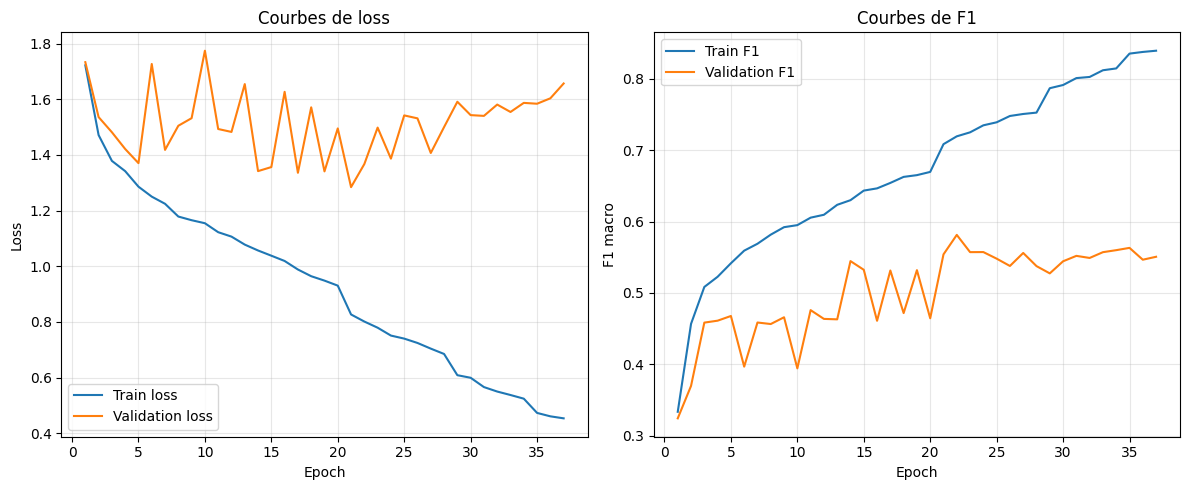

Figure sauvegardée : c:\Users\jayso\Documents\projet-ml\training_curves_cnn_clean_recovered.png


In [50]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train loss")
plt.plot(epochs_range, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbes de loss")
plt.legend()
plt.grid(True, alpha=0.3)

# F1
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_f1"], label="Train F1")
plt.plot(epochs_range, history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("Courbes de F1")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plot_path = os.path.join(BASE_DIR, "training_curves_cnn_clean_recovered.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure sauvegardée :", plot_path)

## Évaluation finale du meilleur modèle sur le jeu de test

Nous rechargeons le meilleur modèle sauvegardé pendant l'entraînement, puis nous l'évaluons sur le jeu de test.

Cette étape fournit le score final à reporter pour cette version du pipeline.

In [51]:
best_model = AudioCNN(num_classes=len(le.classes_)).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_f1, y_true, y_pred = run_eval_epoch(best_model, test_loader, criterion, DEVICE)

print("Test loss :", round(test_loss, 4))
print("Test F1 macro :", round(test_f1, 4))

Test loss : 1.412
Test F1 macro : 0.5536


## Rapport de classification

Nous affichons ici un rapport de classification détaillé afin d'analyser les performances du modèle par classe.

In [52]:
report = classification_report(
    y_true,
    y_pred,
    target_names=le.classes_,
    digits=4
)

print(report)

               precision    recall  f1-score   support

   Electronic     0.6466    0.6515    0.6491       132
 Experimental     0.4628    0.6022    0.5234        93
         Folk     0.5306    0.4333    0.4771        60
      Hip-Hop     0.6842    0.6701    0.6771        97
 Instrumental     0.4904    0.4904    0.4904       104
International     0.7957    0.5692    0.6637       130
          Pop     0.2410    0.3636    0.2899        55
         Rock     0.6786    0.6387    0.6580       119

     accuracy                         0.5747       790
    macro avg     0.5662    0.5524    0.5536       790
 weighted avg     0.6013    0.5747    0.5825       790



## Matrice de confusion

La matrice de confusion permet de visualiser les confusions entre classes et d'identifier les genres les plus difficiles à distinguer.

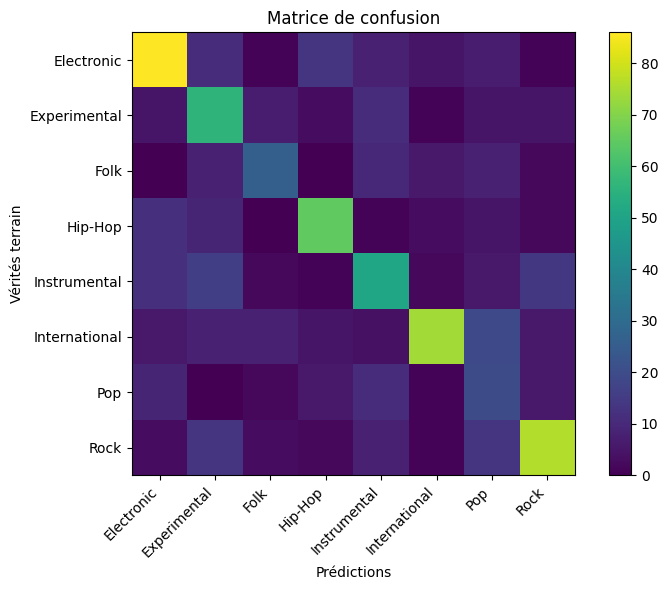

In [53]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Matrice de confusion")
plt.colorbar()
plt.xticks(ticks=np.arange(len(le.classes_)), labels=le.classes_, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(le.classes_)), labels=le.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Vérités terrain")
plt.tight_layout()
plt.show()

## Sauvegarde de l'historique d'apprentissage

Nous sauvegardons ici les métriques de chaque époque dans un fichier CSV afin de faciliter l'analyse et la traçabilité des expériences.

In [54]:
history_df = pd.DataFrame(history)
history_csv_path = os.path.join(BASE_DIR, "training_history_cnn_clean_recovered.csv")
history_df.to_csv(history_csv_path, index=False)

print("Historique sauvegardé :", history_csv_path)
display(history_df.head())

Historique sauvegardé : c:\Users\jayso\Documents\projet-ml\training_history_cnn_clean_recovered.csv


,train_loss,train_f1,val_loss,val_f1
0,1.722037,0.333510,1.733379,0.324337
1,1.471427,0.456734,1.536059,0.369778
2,1.378639,0.508404,1.481629,0.458448
3,1.341766,0.522668,1.421410,0.461154
4,1.285964,0.541572,1.370536,0.467721


## Export des résultats finaux

Nous sauvegardons ici un résumé standardisé de l'expérience finale afin de faciliter la comparaison avec les autres modèles du projet.

Le format d'export regroupe les principales métriques et les paramètres méthodologiques utilisés.

In [55]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

acc_test = accuracy_score(y_true, y_pred)
bal_acc_test = balanced_accuracy_score(y_true, y_pred)

results = [{
    "model": "CNN_logmel",
    "f1_test": round(test_f1, 4),
    "acc_test": round(acc_test, 4),
    "bal_acc_test": round(bal_acc_test, 4),
    "f1_cv_mean": 0,
    "f1_cv_std": 0,
    "duration_s": round(training_time_s, 1),
    "seed": CONFIG["seed"],
    "split": "GroupShuffleSplit 80/10/10",
    "imputer": "None",
    "scaler": "None",
    "n_features": "128 mel x 1291 frames",
    "n_train": len(df_train),
    "n_test": len(df_test),
    "dataset": "FMA_Small"
}]

results_df = pd.DataFrame(results)

results_dir = BASE_DIR / "outputs" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_csv_path = results_dir / "results_jayson.csv"
results_df.to_csv(results_csv_path, index=False)

print("Résultats sauvegardés :", results_csv_path)
print("Le fichier existe ?", results_csv_path.exists())
display(results_df)

Résultats sauvegardés : c:\Users\jayso\Documents\projet-ml\outputs\results\results_jayson.csv
Le fichier existe ? True


,model,f1_test,acc_test,bal_acc_test,f1_cv_mean,f1_cv_std,duration_s,seed,split,imputer,scaler,n_features,n_train,n_test,dataset
0,CNN_logmel,0.5536,0.5747,0.5524,0,0,1002.4,42,GroupShuffleSplit 80/10/10,None,None,128 mel x 1291 frames,6481,790,FMA_Small


## Sauvegarde des courbes d'apprentissage du run courant

Nous sauvegardons ici une figure correspondant exactement au modèle final entraîné dans cette session.

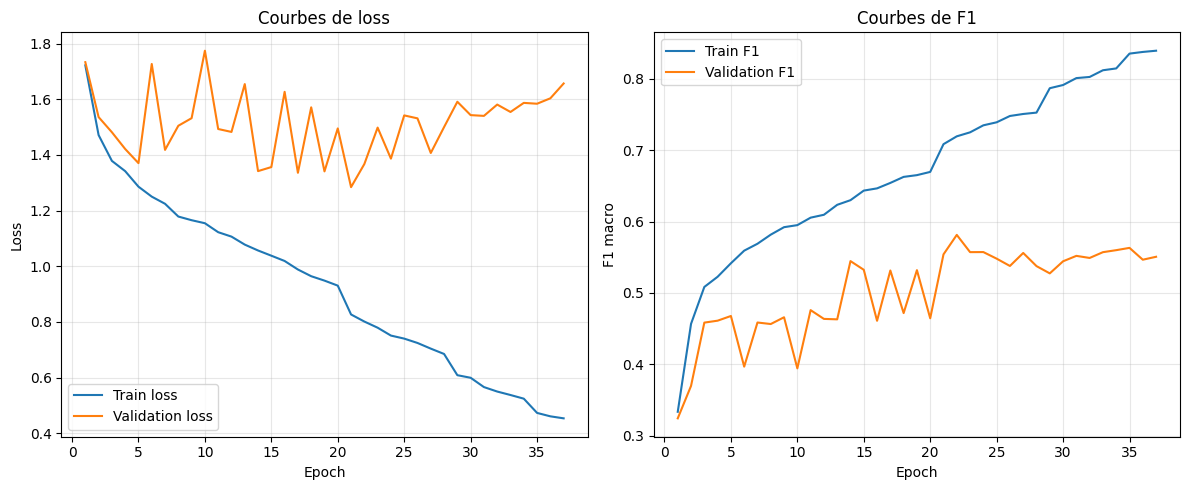

Figure sauvegardée : C:\Users\jayso\Documents\projet-ml\training_curves_cnn_clean_recovered.png


In [52]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train loss")
plt.plot(epochs_range, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbes de loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_f1"], label="Train F1")
plt.plot(epochs_range, history["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("Courbes de F1")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plot_path = os.path.join(BASE_DIR, "training_curves_cnn_clean_recovered.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Figure sauvegardée :", plot_path)

## Conclusion

Dans ce notebook, nous avons construit un pipeline complet de classification audio sur FMA Small :

- préparation des métadonnées,
- génération des spectrogrammes log-mel,
- split par groupes,
- construction d'un pipeline PyTorch propre,
- entraînement d'un CNN performant,
- évaluation finale sur le jeu de test.

La version finale combine :
- une structure de notebook claire et reproductible,
- une architecture CNN enrichie,
- des hyperparamètres permettant de retrouver des performances proches des meilleurs essais précédents.